In [1]:
import pypowsybl.network as pn
import pypowsybl.loadflow as lf
import pypowsybl.report as report
import pandas as pd

In [2]:
network = pn.load('/usr/local/google/home/sxzhou/Downloads/2025 Series RTEP 2030 SUM_06182025.raw', {'psse.import.ignore-base-voltage':'true'})
# network.save("/usr/local/google/home/sxzhou/Downloads/powsybl.m",format="MATPOWER")
# hvdcs=network.get_hvdc_lines().index.tolist()
# pn.remove_hvdc_lines(network,hvdcs)
print(network.get_buses().v_mag.min(),network.get_buses().v_mag.max())
print(network)


0.0 1.3208
Network(id=2025 Series RTEP 2030 SUM_06182025, name=2025 Series RTEP 2030 SUM_06182025, case_date=2026-07-31 16:29:27.515000+00:00, forecast_distance=0:00:00, source_format=PSS/E)


In [6]:
print("Bus: ",len(network.get_buses()))
print("Generators:",len(network.get_generators()))
print("Lines: ",len(network.get_lines()))
print("Two winds: ",len(network.get_2_windings_transformers()))
print("Three winds: ",len(network.get_3_windings_transformers()))
print("Shunts: ",len(network.get_shunt_compensators()))
print("FACTS: ",len(network.get_static_var_compensators()))

Bus:  99345
Generators: 15295
Lines:  90758
Two winds:  25048
Three winds:  4321
Shunts:  10892
FACTS:  79


In [92]:
trans=network.get_lines()
trans.loc["L-94130-219811-1 "]

name                                  
r                             0.000001
x                              0.00001
g1                                 0.0
b1                                 0.0
g2                                 0.0
b2                                 0.0
p1                                 NaN
q1                                 NaN
i1                                 NaN
p2                                 NaN
q2                                 NaN
i2                                 NaN
voltage_level1_id              VL94130
voltage_level2_id      VL219810-219811
bus1_id                      VL94130_0
bus2_id              VL219810-219811_1
connected1                        True
connected2                        True
Name: L-94130-219811-1 , dtype: object

In [88]:
buses.loc["VL640271-640272-640273-640274-643171_0"]

name                                                         
v_mag                                                 1.01489
v_angle                                              -29.0319
connected_component                                         0
synchronous_component                                       0
voltage_level_id         VL640271-640272-640273-640274-643171
Name: VL640271-640272-640273-640274-643171_0, dtype: object

In [90]:
buses.loc['VL640200-640201-640202-640203-643070-643071-643072-653314-653316-653571_9']

name                                                                      
v_mag                                                              1.01064
v_angle                                                           -26.4367
connected_component                                                      0
synchronous_component                                                    0
voltage_level_id         VL640200-640201-640202-640203-643070-643071-64...
Name: VL640200-640201-640202-640203-643070-643071-643072-653314-653316-653571_9, dtype: object

In [17]:
network.save("/usr/local/google/home/sxzhou/Downloads/powsybl.mat",format="MATPOWER")

In [5]:
rp=report.ReportNode()
results=lf.run_ac(
    network,
    report_node=rp,
    parameters=lf.Parameters(
              component_mode=lf.ComponentMode.MAIN_SYNCHRONOUS,
        voltage_init_mode=lf.VoltageInitMode.PREVIOUS_VALUES,
        shunt_compensator_voltage_control_on=False,
        transformer_voltage_control_on=False
    )
  )
print(rp)

+ 
   + Load flow on network '2025 Series RTEP 2030 SUM_06182025'
      + Network CC0 SC0
         203 generators have been discarded from voltage control because of a too small reactive range
         3 generators have been discarded from active power control because of a targetP < minP
         67 generators have been discarded from active power control because of maxP equals to minP
         + Network info
            Network has 101431 buses and 120039 branches
            Network balance: active generation=-2.060218976200861E7 MW, active load=698457.8256330419 MW, reactive generation=74581.56500000019 MVar, reactive load=174110.55092248574 MVar
            Angle reference bus: VL360052-364001-364002-364003_3
            Slack bus: VL360052-364001-364002-364003_3
         Voltage initialization with method Previous Value
         AC load flow completed with error (solverStatus=MAX_ITERATION_REACHED, outerloopStatus=STABLE)



In [157]:
import json
def get_original_id(val):
   val=val[2:]
   seq=int(val.split("_")[1])
   return int(val.split("_")[0].split("-")[seq])

mapping={idx+1:val for idx,val in enumerate(network.get_buses().index.to_list())}
mapping={k:get_original_id(v) for k,v in mapping.items()}
with open("/usr/local/google/home/sxzhou/Downloads/bus_mapping.json","w") as f:
   json.dump(mapping,f)

In [34]:
network = pn.load('/usr/local/google/home/sxzhou/Downloads/pjm-rtep-2032-summer-20250910_original-case_convert.raw',{'psse.import.ignore-base-voltage': 'true'})

In [210]:
hvdcs=network.get_hvdc_lines().index.tolist()
pn.remove_hvdc_lines(network,hvdcs)
shunts=network.get_shunt_compensators()
shunts['section_count']=0
network.update_shunt_compensators(shunts[["section_count"]])

In [79]:
buses.loc["VL693455-693456_0"]

name                                    
v_mag                             1.0201
v_angle                         -45.0587
connected_component                    0
synchronous_component                  0
voltage_level_id         VL693455-693456
Name: VL693455-693456_0, dtype: object

In [80]:
buses.loc["VL693455-693456_1"]

name                                    
v_mag                             1.0201
v_angle                         -45.0587
connected_component                    0
synchronous_component                  0
voltage_level_id         VL693455-693456
Name: VL693455-693456_1, dtype: object

In [78]:
network.get_2_windings_transformers().loc["T-693455-693456-1 "]

name                 J1316 GSU                               
r                                                    0.000097
x                                                    0.000973
g                                                         0.0
b                                                        -0.0
rated_u1                                                  1.0
rated_u2                                                  1.0
rated_s                                                   NaN
p1                                                        NaN
q1                                                        NaN
i1                                                        NaN
p2                                                        NaN
q2                                                        NaN
i2                                                        NaN
voltage_level1_id                             VL693455-693456
voltage_level2_id                             VL693455-693456
bus1_id 

In [ ]:
rp=report.ReportNode()
results=lf.run_ac(
    network,
    report_node=rp,
    parameters=lf.Parameters(
        component_mode=lf.ComponentMode.MAIN_SYNCHRONOUS,
        voltage_init_mode=lf.VoltageInitMode.DC_VALUES,
        distributed_slack=False,
        shunt_compensator_voltage_control_on=False,
        transformer_voltage_control_on=False,
        use_reactive_limits=False,
        provider_parameters={
            "slackBusSelectionMode":"LARGEST_GENERATOR",
             "writeIterationsLog": "true"
          }
       
    )
  )
rp

In [6]:
buses=network.get_buses()
buses=buses[buses["synchronous_component"]==0]
buses.v_mag.describe()

count    97186.000000
mean         1.015358
std          0.022516
min          0.583530
25%          1.003000
50%          1.014685
75%          1.026450
max          1.320800
Name: v_mag, dtype: float64

In [214]:
gens=network.get_generators()
gens=gens[gens["bus_id"]=="VL360052-364001-364002-364003_3"]
gens

,name,energy_source,target_p,min_p,max_p,min_q,max_q,rated_s,reactive_limits_kind,target_v,target_q,voltage_regulator_on,regulated_element_id,p,q,i,voltage_level_id,bus_id,connected
id,,,,,,,,,,,,,,,,,,,
B364003-G1,,OTHER,1279.726,1225.0,1302.5,50.0,277.25,NaN,MIN_MAX,1.04,280.205,True,L-360014-360052-1,NaN,NaN,NaN,VL360052-364001-364002-364003,VL360052-364001-364002-364003_3,True


In [154]:
def get_bus_substation(network: pn, bus_id: str):
    buses = network.get_buses()
    volt_levels = network.get_voltage_levels()
    bus = buses.loc[bus_id]["voltage_level_id"]

    return volt_levels.loc[bus]["substation_id"]

get_bus_substation(network,"VL135413-135450_1")

'S135413-135450'

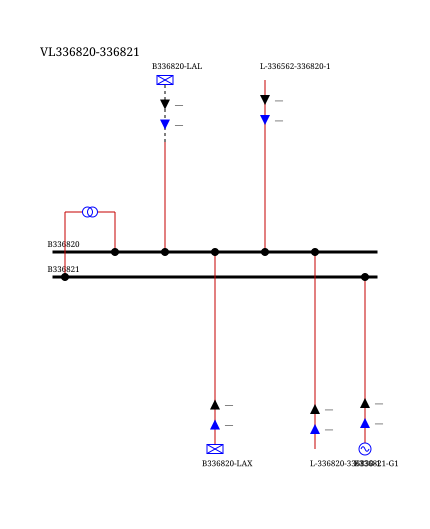

In [162]:
network.get_single_line_diagram(container_id="S336820-336821")

In [107]:
buses=network.get_buses()
buses=buses[(buses["connected_component"]==0)&(buses["synchronous_component"]==0)]
buses

,name,v_mag,v_angle,connected_component,synchronous_component,voltage_level_id
id,,,,,,
VL94130_0,,NaN,NaN,0,0,VL94130
VL94150_0,,NaN,NaN,0,0,VL94150
VL99210_0,,NaN,NaN,0,0,VL99210
VL99211_0,,NaN,NaN,0,0,VL99211
VL100001_0,,NaN,NaN,0,0,VL100001
...,...,...,...,...,...,...
VL940862-940863_1,,NaN,NaN,0,0,VL940862-940863
VL942021-942022-942023_0,,NaN,NaN,0,0,VL942021-942022-942023
VL942021-942022-942023_1,,NaN,NaN,0,0,VL942021-942022-942023


In [79]:
network.get_voltage_levels().loc["VL158007-158070-158744-158745-158864"]

name                                                     
substation_id         S158007-158070-158744-158745-158864
nominal_v                                             1.0
high_voltage_limit                                    NaN
low_voltage_limit                                     NaN
Name: VL158007-158070-158744-158745-158864, dtype: object

In [9]:
network = pn.load('/usr/local/google/home/sxzhou/Downloads/PJMRTEP2029Summer20251218Test_2024 Series RTEP 2029 SUM_Final_convert.raw', {'psse.import.ignore-base-voltage':'true'})
buses=network.get_buses()
buses.v_mag.max()

np.float64(1.30524)

In [21]:
from psbl import subs_with_volt_violations

subs=subs_with_volt_violations(network,5)
subs

[BusInfo(id='VL158007-158070-158744-158745-158864_2', substation_id='S158007-158070-158744-158745-158864', v_mag=1.30524),
 BusInfo(id='VL156435-156436-156468-156698-156736_2', substation_id='S156435-156436-156468-156698-156736', v_mag=1.25926),
 BusInfo(id='VL160227-160744_1', substation_id='S160227-160744', v_mag=1.25335),
 BusInfo(id='VL151059-151701_1', substation_id='S151059-151701', v_mag=1.22377),
 BusInfo(id='VL152148-152149-152425-152821-152822_0', substation_id='S152148-152149-152425-152821-152822', v_mag=1.21481)]

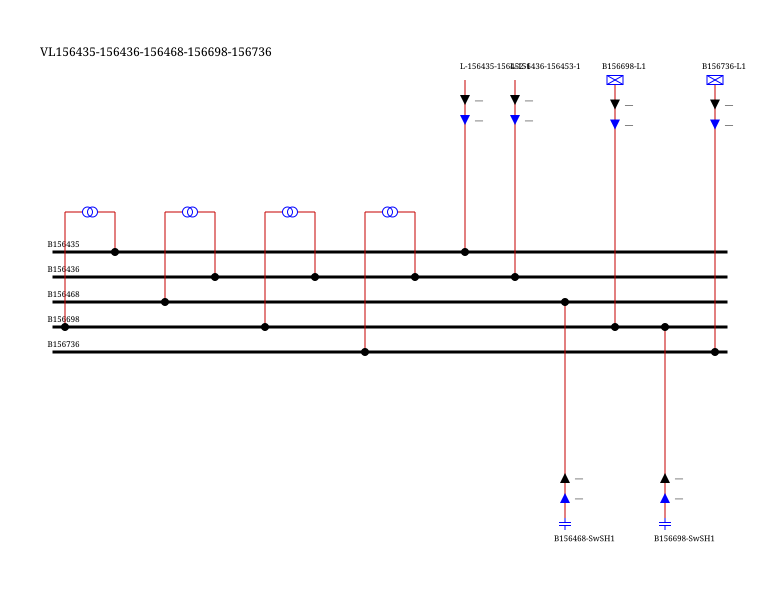

In [22]:
network.get_single_line_diagram(subs[1].substation_id)

In [28]:
shunts=network.get_shunt_compensators()
shunts[shunts["bus_id"]=="VL156435-156436-156468-156698-156736_2"]

,name,g,b,model_type,max_section_count,section_count,solved_section_count,voltage_regulation_on,target_v,target_deadband,regulating_bus_id,p,q,i,voltage_level_id,bus_id,connected
id,,,,,,,,,,,,,,,,,
B156468-SwSH1,,0.0,39.68,NON_LINEAR,3,3,NaN,False,NaN,NaN,VL156435-156436-156468-156698-156736_2,NaN,NaN,NaN,VL156435-156436-156468-156698-156736,VL156435-156436-156468-156698-156736_2,True


In [8]:
import numpy as np 
np.radians(1.5)/0.000212

np.float64(123.49027726374973)

np.float64(2143.386800694791)